This notebook tests basic simulation by recapitulating a simulated dataset several times and measuring variance.

Imports

In [1]:
import sys
import os
package_path = os.path.abspath("..")
sys.path.insert(0, package_path)
#The path will be managed by conda or whatever on release, but this is fine for now.
import scMPRAforge as scm
import pandas as pd
import numpy as np

In [1]:
#load the autoreload extension
%load_ext autoreload
#reload code on every execution
#(this may break objects)
#you can remove this & do dev in a notebook, then paste into the module when you are done.
%autoreload 2

In [2]:
#dask imports
from dask_jobqueue import SLURMCluster
from dask.distributed import Client, LocalCluster
import socket

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

Make the dask cluster & client in accordance with resource avail and model size

In [ ]:
cluster=LocalCluster()
#cluster=SLURMCluster(
#    cores=2,#cores per slurm job
#    memory="16G",#memory per slurm job
#    processes=1,#dask workers per slurm job
#    job_extra_directives=["-p ycga", 
#        f"--job-name=simclust_worker",
#        f"--time=2:00:00",
#        f"--output=slave_%j.out"]
#)
client = Client(cluster,
    timeout=f"{5*60}s",   # Client <-> scheduler timeout 
    heartbeat_interval="20s"  # Worker heartbeat interval
)

2025-06-11 12:57:52,346 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 767b2f73ba2c129724542cb73872bee6 initialized by task ('shuffle-transfer-767b2f73ba2c129724542cb73872bee6', 1) executed on worker tcp://127.0.0.1:52663
2025-06-11 12:57:52,366 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 11a9ccc17a2f5df4f6527860b59047f6 initialized by task ('shuffle-transfer-11a9ccc17a2f5df4f6527860b59047f6', 0) executed on worker tcp://127.0.0.1:52673
2025-06-11 12:57:52,615 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 767b2f73ba2c129724542cb73872bee6 deactivated due to stimulus 'task-finished-1749661072.6152608'
2025-06-11 12:57:52,865 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 11a9ccc17a2f5df4f6527860b59047f6 deactivated due to stimulus 'task-finished-1749661072.865377'
2025-06-11 12:58:17,992 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 4a0cd5bdd5cf9e961c45b1abb965d00f initialized by task ('shuffle-transfer-4a0cd5bdd5cf9e9

In [5]:
dat=scm.load_scMPRA_data("/gpfs/gibbs/pi/reilly/tabula_data/simulated/fake_cres.tsv")
dat.drop("Unnamed: 0", axis=1, inplace=True)
#let's make an ortho object out of the data on disc, we'll call 'primordial'
primordial=scm.ortho()
primordial.criss_cross(client=client,dat=dat)
primordial.extract_params(client)

In [6]:
batch=scm.simulation_batch(primordial)
batch.describe_primordial(client,dat)

In [8]:
batch.simulate_many(client,3)

In [9]:
batch.fit_to_simulations(client)

In [10]:
batch._flatten_all_parameters()

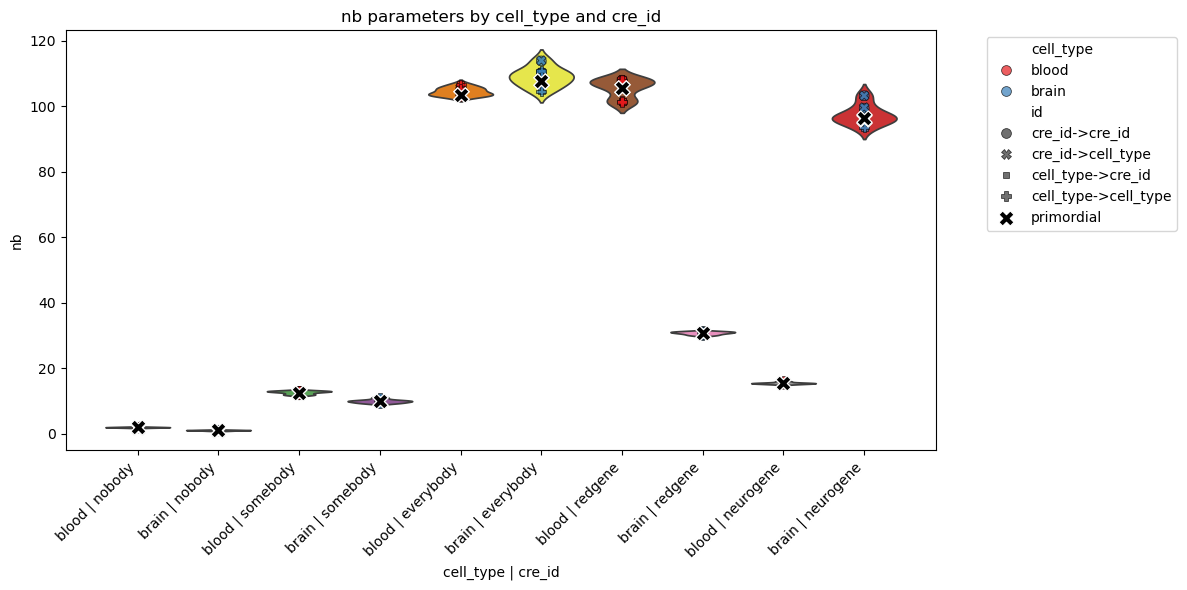

In [11]:
batch.plot_nb_spread()

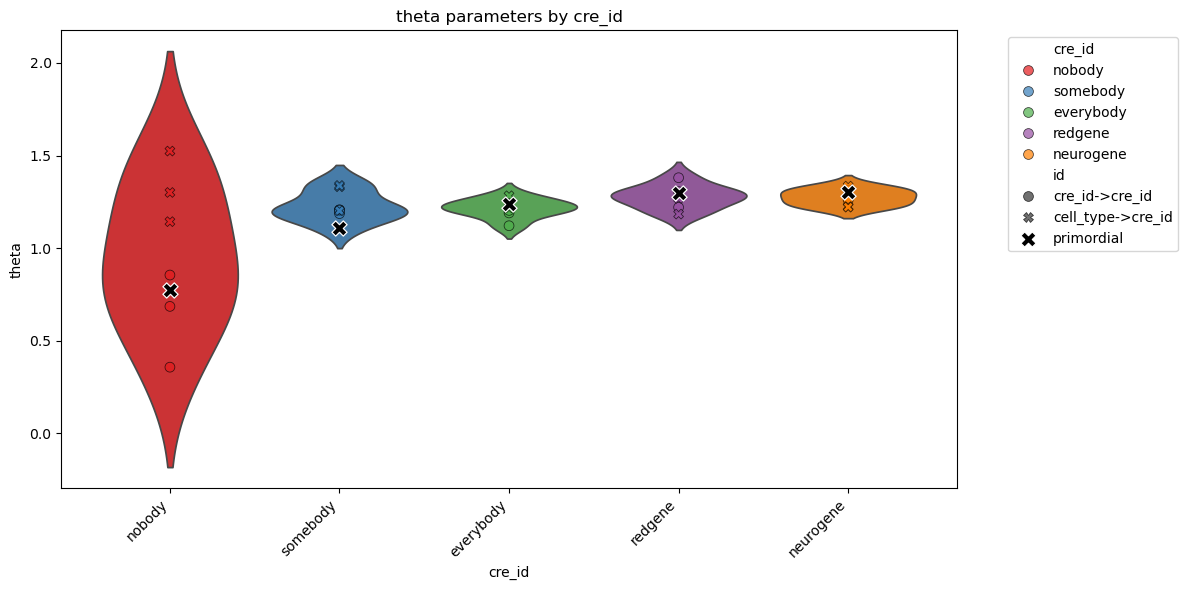

In [12]:
batch.plot_theta_spread("cre_id")

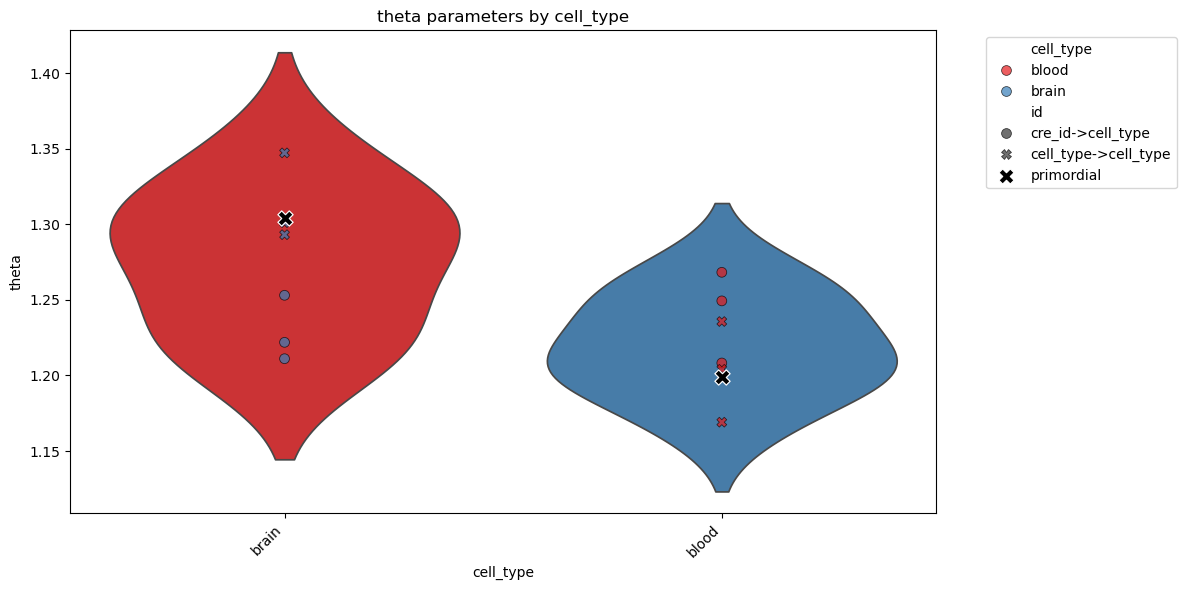

In [13]:
batch.plot_theta_spread("cell_type")

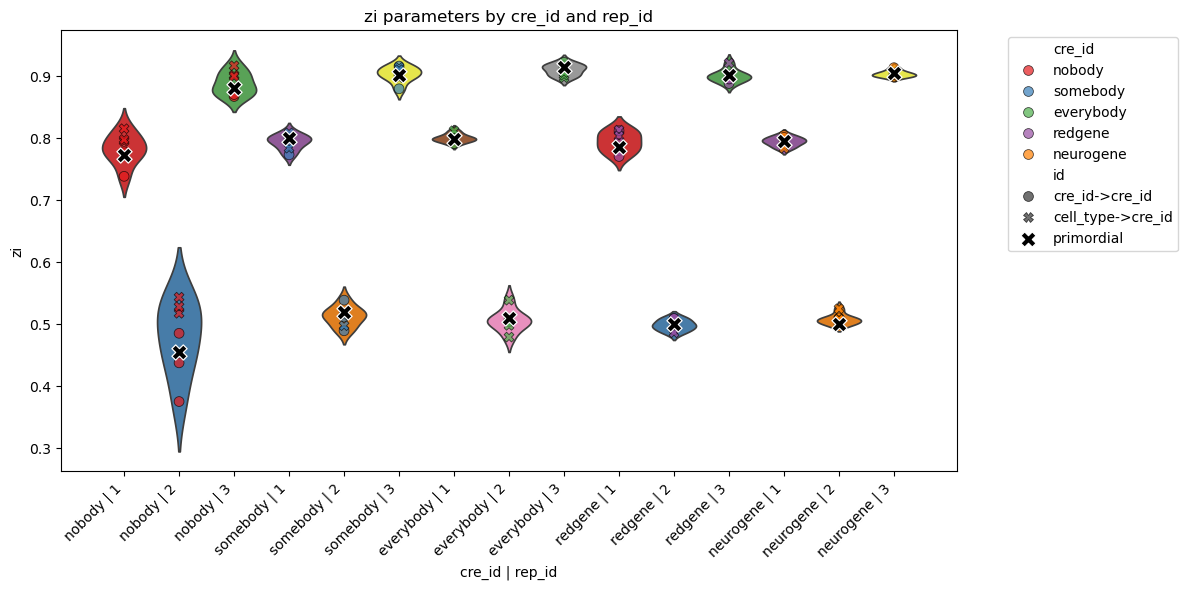

In [14]:
batch.plot_zi_spread("cre_id")

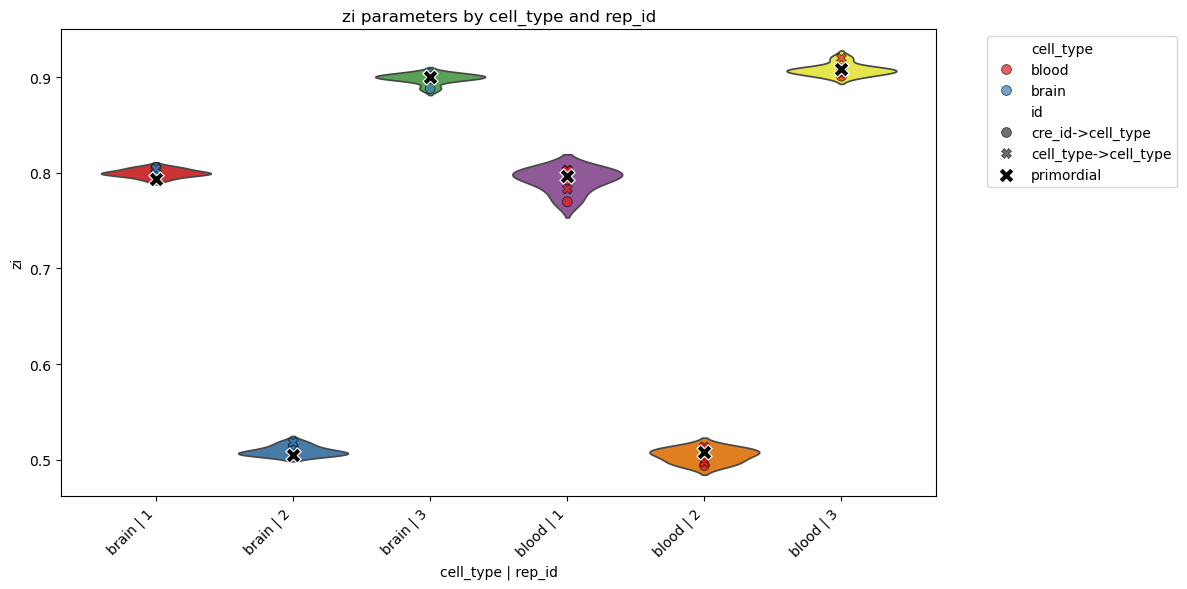

In [15]:
batch.plot_zi_spread("cell_type")

In [16]:
cluster.close()